## Location Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis (EDA) on the Location on the Airbnb listings dataset. 
The goal is identify patterns and gain insights.

In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# Load the processed listings dataset into the Dataframe
df = pd.read_csv("../data/processed/processed_listings.csv")

In [17]:
# Quick inspection of the data
df.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review
0,0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,True
1,1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,True
2,2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,0.00,1,365,False
3,3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,True
4,4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,True


In [18]:
# Neighbourhood Group with the most listings
neighbourhood_group = df["neighbourhood_group"].value_counts()
neighbourhood_group


neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

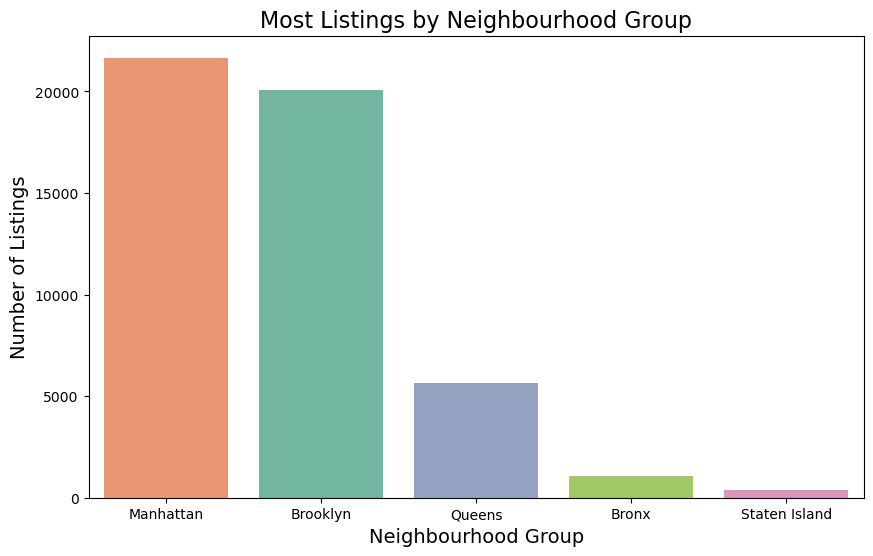

In [19]:
# Plotting the neighbourhood group with the most listings
plt.figure(figsize=(10, 6))
sns.countplot(x="neighbourhood_group", data=df, order=neighbourhood_group.index, palette="Set2", hue="neighbourhood_group", legend=False)
plt.title("Most Listings by Neighbourhood Group", fontsize=16)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.ylabel("Number of Listings", fontsize=14)
plt.savefig("../outputs/neighbourhood_with_most_listings.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Average price of listings by neighbourhood group
avg_price_by_neighbourhood_group = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
avg_price_by_neighbourhood_group

neighbourhood_group
Manhattan        196.884903
Brooklyn         124.438915
Staten Island    114.812332
Queens            99.517649
Bronx             87.577064
Name: price, dtype: float64

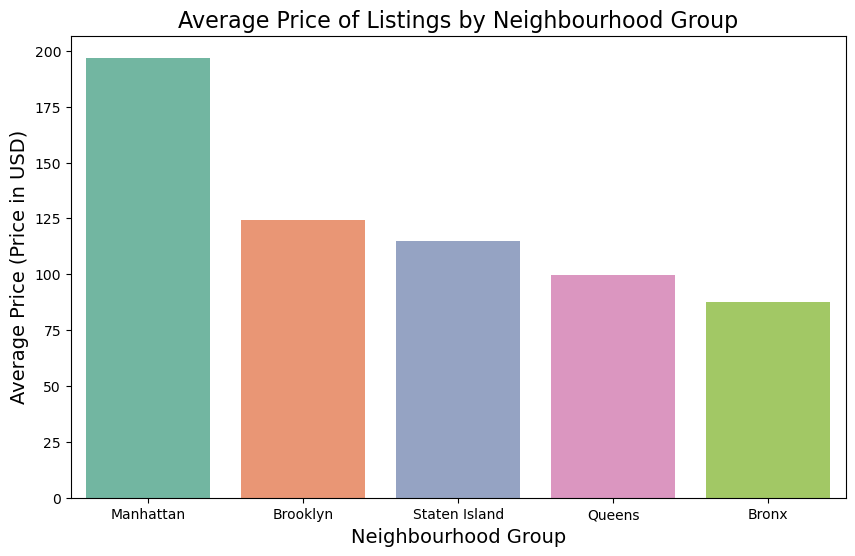

In [21]:
# Plotting the average price of listings by neighbourhood group
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_by_neighbourhood_group.index, y=avg_price_by_neighbourhood_group.values, palette="Set2", hue=avg_price_by_neighbourhood_group.index, legend=False)
plt.title("Average Price of Listings by Neighbourhood Group", fontsize=16)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.ylabel("Average Price (Price in USD)", fontsize=14)
plt.savefig("../outputs/average_price_by_neighbourhood_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Top expensive neighbourhood groups
top_expensive_neighbourhood_group = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
top_expensive_neighbourhood_group

neighbourhood_group
Manhattan        196.884903
Brooklyn         124.438915
Staten Island    114.812332
Queens            99.517649
Bronx             87.577064
Name: price, dtype: float64

In [23]:
# Top expensive neighbourhood
top_expensive = df.groupby(["neighbourhood", "neighbourhood_group"])["price"].mean().sort_values(ascending=False).head(10)
top_expensive

neighbourhood      neighbourhood_group
Fort Wadsworth     Staten Island          800.000000
Woodrow            Staten Island          700.000000
Tribeca            Manhattan              490.638418
Sea Gate           Brooklyn               487.857143
Riverdale          Bronx                  442.090909
Prince'S Bay       Staten Island          409.500000
Battery Park City  Manhattan              367.557143
Flatiron District  Manhattan              341.925000
Randall Manor      Staten Island          336.000000
Noho               Manhattan              295.717949
Name: price, dtype: float64

In [24]:
# Cheapest neighbourhood
cheapest_neighbourhood = df.groupby(["neighbourhood", "neighbourhood_group"])["price"].mean().sort_values().head(10)
cheapest_neighbourhood

neighbourhood   neighbourhood_group
Bull'S Head     Staten Island          47.333333
Hunts Point     Bronx                  50.500000
Tremont         Bronx                  51.545455
Soundview       Bronx                  53.466667
New Dorp        Staten Island          57.000000
Bronxdale       Bronx                  57.105263
New Dorp Beach  Staten Island          57.400000
Grant City      Staten Island          57.666667
Concord         Staten Island          58.192308
Mount Eden      Bronx                  58.500000
Name: price, dtype: float64

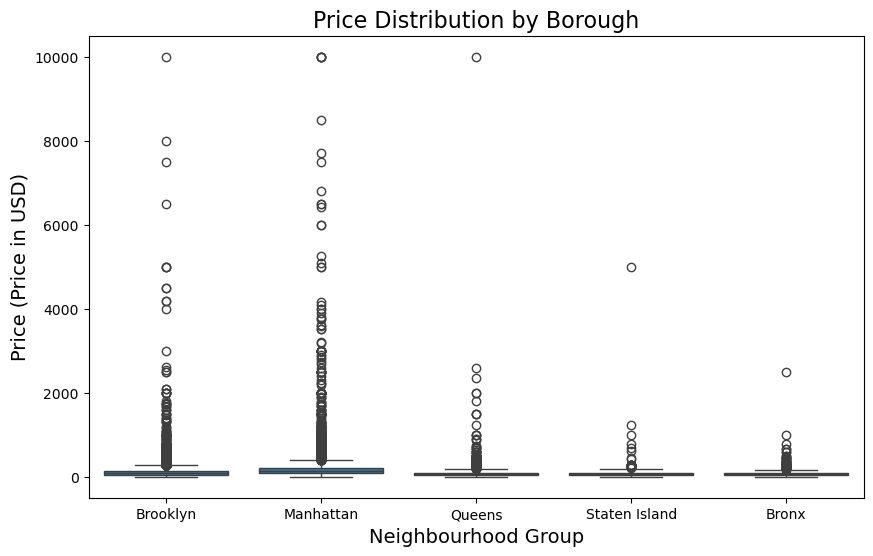

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.ylabel("Price (Price in USD)", fontsize=14)
plt.title("Price Distribution by Borough", fontsize=16)
plt.savefig("../outputs/price_distribution_by_borough.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of Location EDA

This exploratory data analysis (EDA) focused on the geographical aspects of Airbnb listings in New York City, examining neighbourhood groups and neighbourhoods to uncover patterns in listing distribution and pricing.

- **Listing Distribution by Neighbourhood Group**: Manhattan has the highest number of listings (21,660), followed by Brooklyn (20,095), Queens (5,666), Bronx (1,090), and Staten Island (373).
- **Average Price by Neighbourhood Group**: Manhattan has the highest average price at approximately $197, while the Bronx has the lowest at about $88.
- **Top Expensive Neighbourhoods**: The most expensive neighbourhoods include Fort Wadsworth (Staten Island, $800), Woodrow (Staten Island, $700), and Tribeca (Manhattan, $491).
- **Cheapest Neighbourhoods**: The least expensive neighbourhoods are Bull's Head (Staten Island, $47), Hunts Point (Bronx, $50), and Tremont (Bronx, $52).
- **Price Distribution**: A boxplot analysis shows significant price variation across neighbourhood groups, with Manhattan exhibiting the widest range and highest median prices.

These insights highlight Manhattan as the dominant area for both listings and pricing, while Staten Island and the Bronx offer more affordable options.